# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [23]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

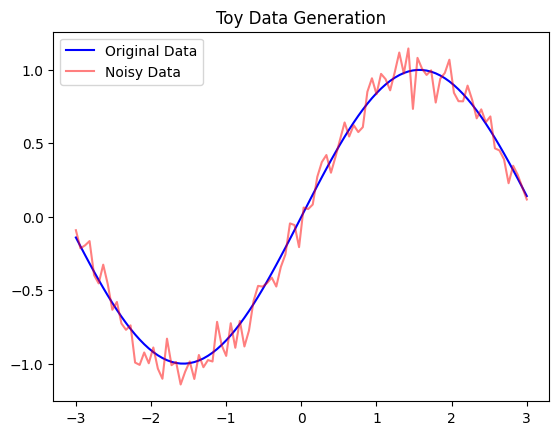

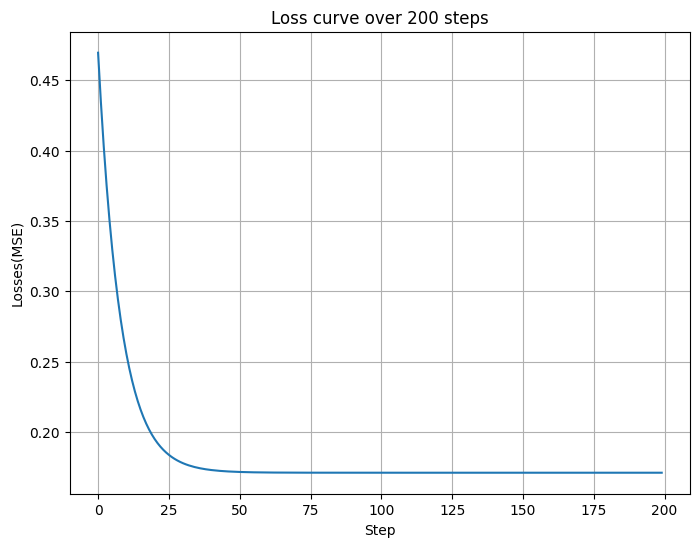

In [24]:
# TODO: Generate the toy data
from numpy import random 


x = np.linspace(-3, 3, 100)
y = np.sin(x) 
noise = np.random.normal(0, 0.1, 100)

plt.plot(x, y, color='blue')
plt.plot(x, y + noise, color='red', alpha=0.5)
plt.legend(["Original Data", "Noisy Data"])
plt.title("Toy Data Generation")
plt.show()
#   Plot it.

# TODO: Initialise w and b to small random values.
w = np.random.random() * 0.01
b = np.random.random() * 0.01



# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#initializing weights and learning rate 

lr = 0.01

#done for one step 
y_hat = w * x + b
loss  = np.mean((y_hat - y) ** 2)               # MSE
dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
db    = np.mean(2 * (y_hat - y))                # dLoss/db
w    -= lr * dw
b    -= lr * db

#storing the loss for each step.
losses = []
#for loop for iteration over 200 steps 
for i in range(200): 
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)               
  dw    = np.mean(2 * (y_hat - y) * x)            
  db    = np.mean(2 * (y_hat - y))                
  w    -= lr * dw
  b    -= lr * db
  losses.append(loss)


#plotted curve 
plt.figure(figsize = (8,6))
plt.plot(losses) 
plt.xlabel('Step')
plt.ylabel('Losses(MSE)')
plt.title('Loss curve over 200 steps')
plt.grid(True)
plt.show()



**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
![alt text](derivation-1.jpeg)





*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*


> **Answer:** The model is underfitting because it is simple to capture the underlying pattern. The reason for this is that a single neuron being used without an activation function is non linear and hance is not able to capture all the necessary information to discover the relevant patterns in  a sine wave which is non linear. 

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

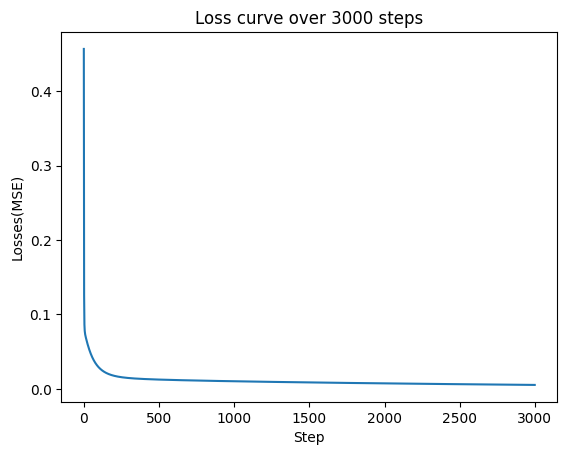

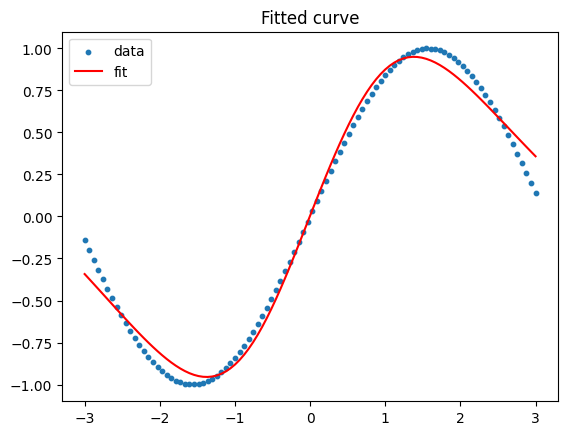

In [25]:
# TODO: Initialise parameters
x = x.reshape(-1,1) 
y = y.reshape(-1,1) 

np.random.seed(0) 
lr = 0.05 

W1 = np.random.randn(1, 8) *0.5
b1 = np.random.rand(8,) *0.5 
W2 = np.random.randn(8, 1) *0.5
b2 = np.random.rand(1,) *0.5

losses = []

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
for step in range(3000):
    z1 = x @ W1 + b1
    h  = np.tanh(z1)  # hidden layer
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
    d_yhat = 2 *(y_hat - y) 
    dW2 = np.mean(h*d_yhat, axis=0).reshape(8,1) 
    db2 = np.mean(d_yhat, axis=0)

    dh = d_yhat @ W2.T  
    dz1 = dh * (1 -np.tanh(z1) **2) 
    dW1 = np.mean(x *dz1, axis=0).reshape(1,8) 
    db1 = np.mean(dz1, axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

plt.figure() 
plt.plot(losses) 
plt.xlabel('Step')
plt.ylabel('Losses(MSE)')
plt.title('Loss curve over 3000 steps') 
plt.show() 


plt.figure() 
plt.scatter(x,y, s=10, label ="data")
plt.plot(x, y_hat, color ='red', label ='fit')
plt.legend() 
plt.title("Fitted curve")
plt.show()


###without tanh 




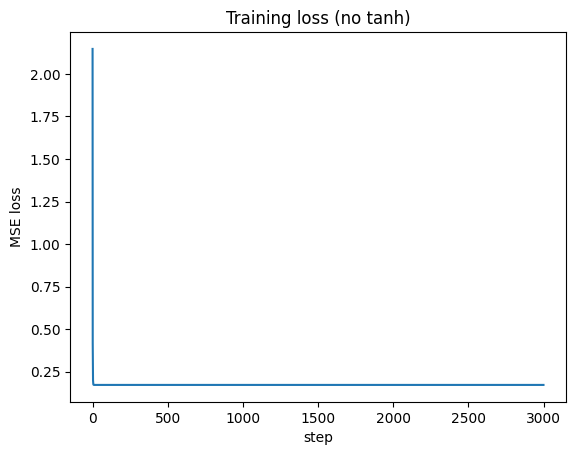

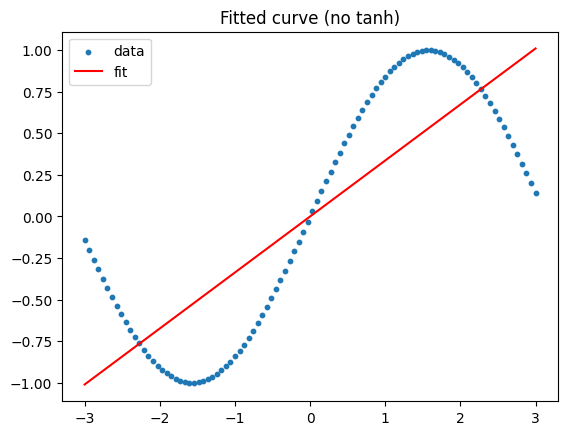

In [26]:

lr = 0.05

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

losses = []

for step in range(3000):
    z1 = x @ W1 + b1
    h  = z1                       # tanh removed
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y)
    dW2 = np.mean(h * d_yhat, axis=0).reshape(8, 1)
    db2 = np.mean(d_yhat, axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh                      # tanh derivative removed
    dW1 = np.mean(x * dz1, axis=0).reshape(1, 8)
    db1 = np.mean(dz1, axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

plt.figure()
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("MSE loss"); plt.title("Training loss (no tanh)")
plt.show()

plt.figure()
plt.scatter(x, y, s=10, label="data")
plt.plot(x, y_hat, color="red", label="fit")
plt.legend(); plt.title("Fitted curve (no tanh)")
plt.show()

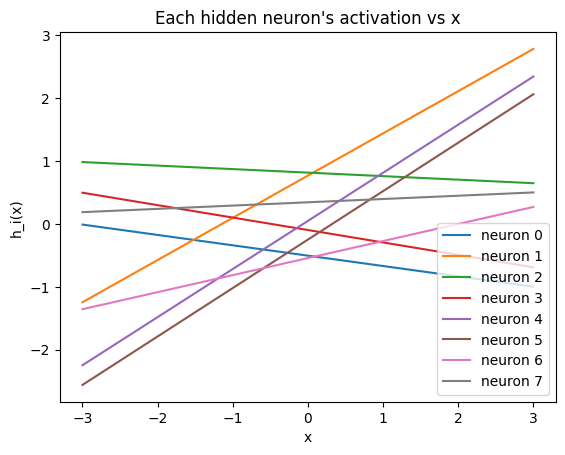

In [27]:
plt.figure()
for i in range(8):
    plt.plot(x, h[:, i], label=f"neuron {i}")
plt.xlabel("x"); plt.ylabel("h_i(x)")
plt.title("Each hidden neuron's activation vs x")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
when tanh is removed. 
h = xW1 + b1 
y_hat = hW2 + b2 

substituting in to equation 2 
y_hat = (xW1+b1)W2 + b2 
an expansion shows we're always going to get a single matrix combined plus some bias combined which is the same shape as 
w*x +b no linearity introduced. therefore no matter how many linear layers are stacked they end up collapsing to a linear function.


*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*

##withtan cell run immediately before running the visualization.
Each hidden neuron produced its own tanh shifted by its own weight and bias. they dont resemble the function we are trying to predict which is the sine function but after the combination it approximates the curvature of the sine curve.



*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*
It is an algorithm that computes how much each weight contributes to the final error by applying the chain rule backward from the loss through each layer so that the gradient descent knows the direction every parameter should move towards. 

> **Answer:** [Double-click to edit]

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

e:\COMPUTING\programming\New folder\%USERPROFILE%\ai_labs\ai_env\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Master\AppData\Local\Temp\ipykernel_2220\1629954196.py:13: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\Master\AppData\Local\Temp\ipykernel_2220\1629954196.py:19: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
C:\Users\Master\AppData\Local\Temp\ipykernel_2220\1629954196.py:20: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
e:\COMPUTING\programming\New folder\%USERPROFILE%\ai_labs\ai_env\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


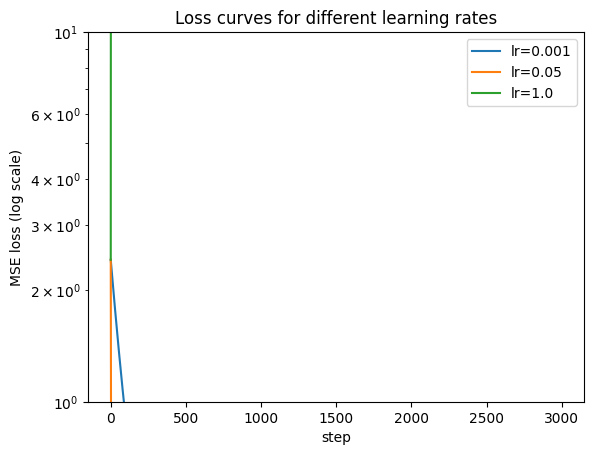

In [32]:
def train_toy(lr, steps=3000):
    np.random.seed(0)  # reset seed each time for a fair comparison across learning rates
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []
    for step in range(steps):
        z1 = x @ W1 + b1
        h  = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y)
        dW2 = np.mean(h * d_yhat, axis=0).reshape(8, 1)
        db2 = np.mean(d_yhat, axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = np.mean(x * dz1, axis=0).reshape(1, 8)
        db1 = np.mean(dz1, axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

losses_small = train_toy(lr=0.001)
losses_mid   = train_toy(lr=0.05)
losses_large = train_toy(lr=1.0)

plt.figure()
plt.plot(losses_small, label="lr=0.001")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_large, label="lr=1.0")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE loss (log scale)")
plt.title("Loss curves for different learning rates")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*
Comparing the three learning rates with lr = 0.001 it converges but slowly lr = 0.05 converges faster lr=1.0 instead of decreasing it shoots up to infinity. showes that 0.05 is the best rate and learning rates have to be tuned carefully because too small wastes training time and too large breaks training.

> **Answer:** [Double-click to edit]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [15]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder 

random_state = 42 
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

df = pd.read_csv(OBESITY_URL)


# TODO: Encode categoricals exactly as you did in Lab 2
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols: 
  df[col] = df[col].map({"yes":1, "no":"0"})

df["Gender"] = df["Gender"].map({"Male":0, "Female":1})

freq_map = {"no":0, "Sometimes":1, "Frequently" :2, "Always": 3}
df["CAEC"] = df["CAEC"].map(freq_map)
df["CALC"] = df["CALC"].map(freq_map)

df = pd.get_dummies(df, columns = ["MTRANS"], drop_first=True)

label_encoder = LabelEncoder() 
df["NObeyesdad"] = label_encoder.fit_transform(df["NObeyesdad"])
class_names = label_encoder.classes_ 

X = df.drop(columns=["NObeyesdad"]).values.astype(np.float32)
y = df["NObeyesdad"].values

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
#splitting between training data and other data 
X_train, X_temp, y_train, y_temp = train_test_split(
  X, y, test_size = 0.4, stratify=y, random_state = random_state
)

#splitting between the validation and testing. 
X_val, X_test, y_val, y_test = train_test_split(
  X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state = random_state
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)





# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)




**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
This is done for memory efficiency and computational efficiency. With one-hot encoding or with one-hot vectors there are a bunch of zeros that PyTorch would need to compute. PyTorch ultimately just needs a specific index for a lookup so there's no need fo rthose redundant computations.


*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
With random forest, it's one feature at a time being split so raw scales dont matter. However with neural networks gradients are computed in such a way that the input value x directly multiplies with the gradient so features which have raw values that are large will produce large gradients. dw = mean(x*dz1) we can see x multiplying the gradient here. this causes larger gradients than small-scale features and when weights are being updated in backpropagation the weights will be updated unevenly because the raw values being large would make the algorithm think that it contributes more. scaling here then equalizes the feature magnitudes.



*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*
It makes DataLoader reorder rows before each epoch. Not doing this can lead to bias gradient updates and cause overfitting.
> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [19]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.



class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes = (64,32), n_classes=7, dropout=0.0):
    super().__init__()
    layers = []
    prev_size = input_dim 
    for h in hidden_sizes: 
      layers.append(nn.Linear(prev_size, h))
      layers.append(nn.ReLU())
      if dropout>0: 
        layers.append(nn.Dropout(dropout))
      prev_size = h 
    
    layers.append(nn.Linear(prev_size, n_classes))
    self.net = nn.Sequential(*layers)

  def forward(self,x):
    return self.net(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeedForwardNet(input_dim = X_train.shape[1]).to(DEVICE)
print(model) 

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", n_params)

print("First layer by hand:", X_train.shape[1] *64 +64)
  

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3591
First layer by hand: 1280



**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
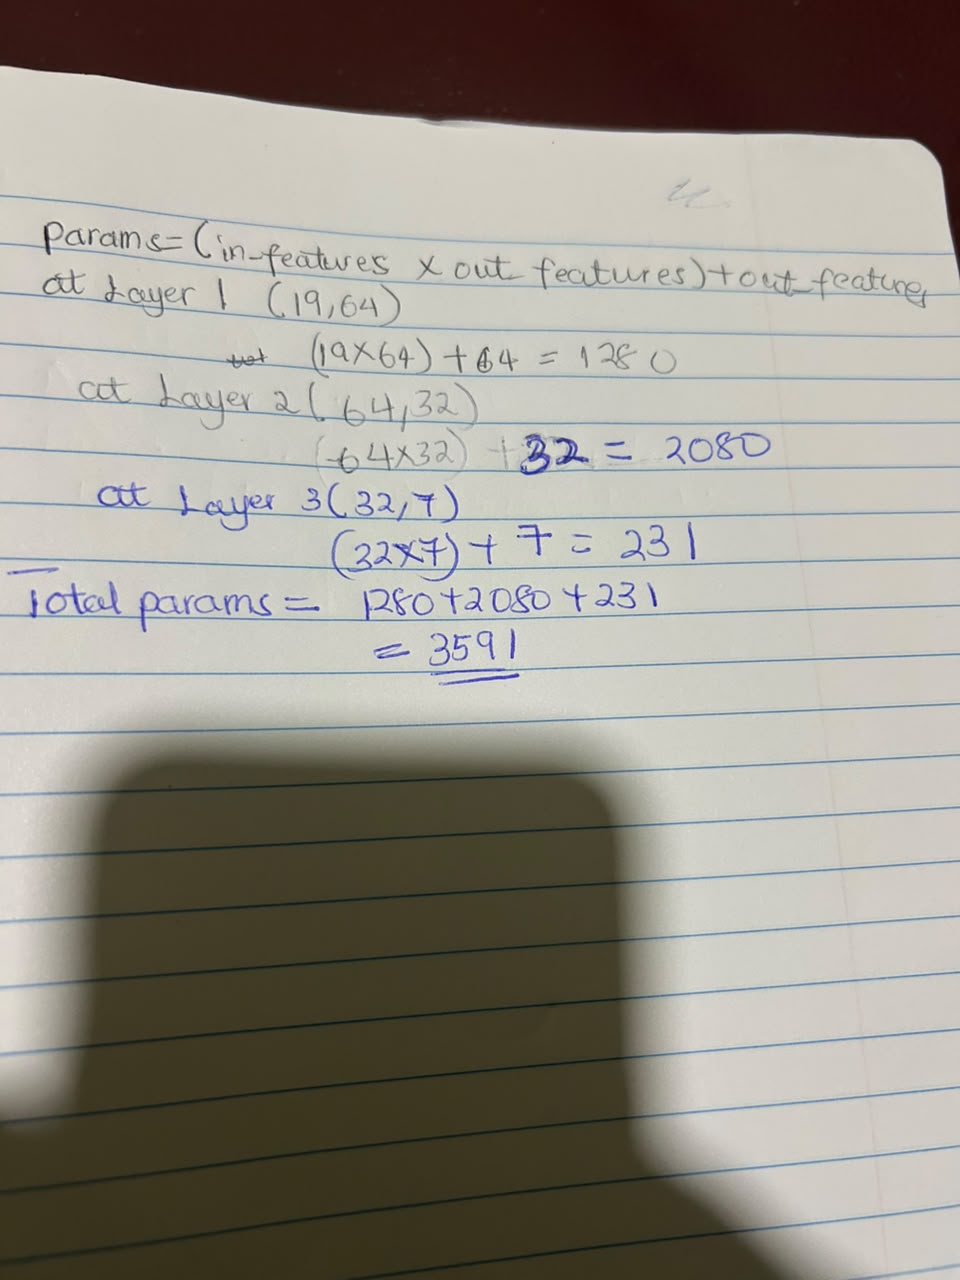


*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
Reku is cheaper to compute and fixes the vanishing gradient problem that tanh has. For large negatives tanh's derivative becomes very close to 0 and hence can't communicate any significant signal to be used in changing weight it makes early layer train very slowly for this reason. ReLU is either 0 or 1 so gradients don't shrink


*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

It would make it purely linear. The point of it is to introduce non linearity without it we would just have linear combinations of w1w2w3 no matter the number of layers 
> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

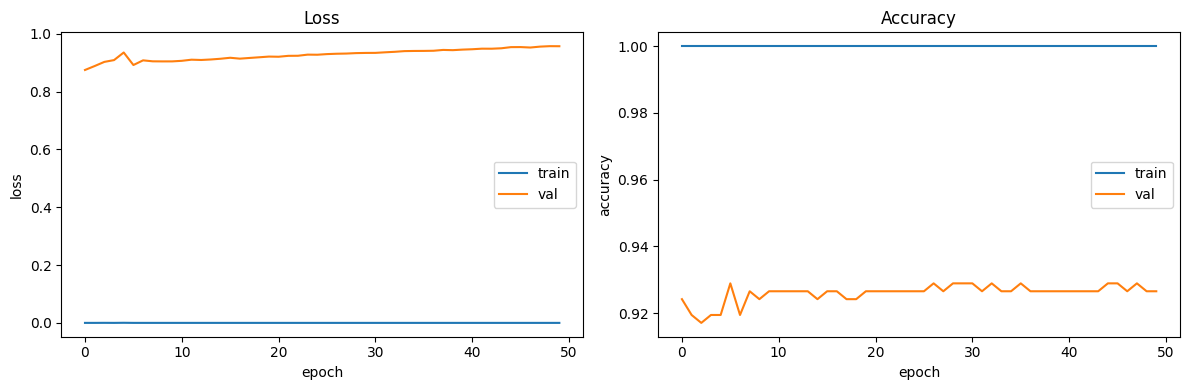

Final train acc: 1.0
Final val acc: 0.9265402843601895
Final train loss: 1.2392587813959875e-06
Final val loss: 0.957217318328071


In [33]:
# TODO: 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0
# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

for epoch in range(50):
  model.train()
  for xb, yb in train_loader: 
    optimizer.zero_grad() 
    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward() 
    optimizer.step()

  model.eval() 
  with torch.no_grad():
    train_correct, train_total,train_loss_sum = 0,0,0.0
    for xb, yb in train_loader: 
      logits = model(xb.to(DEVICE))
      yb = yb.to(DEVICE)
      loss = criterion(logits, yb)
      train_loss_sum +=loss.item() * xb.size(0)
      train_correct += (logits.argmax(dim=1)==yb).sum().item()
      train_total+= xb.size(0)
    train_loss = train_loss_sum/train_total 
    train_acc = train_correct/train_total 


    val_correct, val_total, val_loss_sum = 0, 0, 0.0
    for xb, yb in val_loader:
          logits = model(xb.to(DEVICE))
          yb = yb.to(DEVICE)
          loss = criterion(logits, yb)
          val_loss_sum += loss.item() * xb.size(0)
          val_correct += (logits.argmax(dim=1) == yb).sum().item()
          val_total += xb.size(0)
    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total 

  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_accs.append(train_acc)
  val_accs.append(val_acc)

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
  if val_acc> best_val_acc: 
    best_val_acc = val_acc 
    torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout() 
plt.show()

print("Final train acc:", train_accs[-1])
print("Final val acc:", val_accs[-1])
print("Final train loss:", train_losses[-1])
print("Final val loss:", val_losses[-1])

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*

logits = model(xb.to(DEVICE)) maps to the forward pass which is the same as z1 = w@W1+b1; h=tanh(z1); y_hat = h@W2+b2 

loss = criterion(logits, yb.to(DEVICE)) maps to the loss = np.mean((y_hat-y)**2) this uses cross-entropy instead of mse.

loss.backward() this is the entire backward pass it maps to the gradients being calculated manually in the previous section from d_yhat, dW2, db2, dh, dz1, dW1, db1

the optimizer step maps to the changing or updating of the weights from the learning rates. 



*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*

the model is overfitting because it has a training loss of 0.0000124 which is basically zero for the training data but for the validation it has 92.65 percent and validation loss is 0.957. training loss near zero combined with validation loss near 1.0 shows the model has just simply memorized the training set and didnt learn patterns. 

*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*
PyTorch adds up gradients. without calling zero grad gradients will keep adding this would result in the training being unstable. 
> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

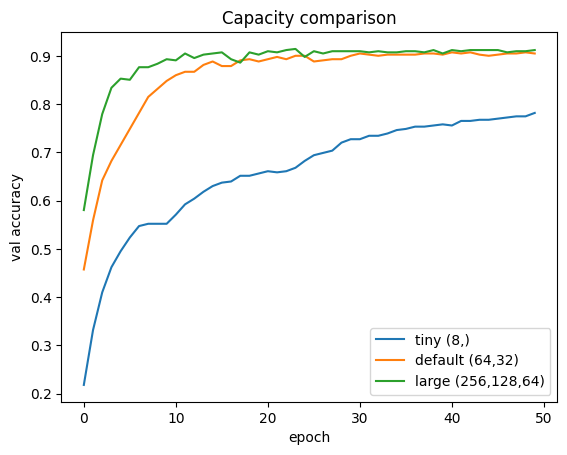

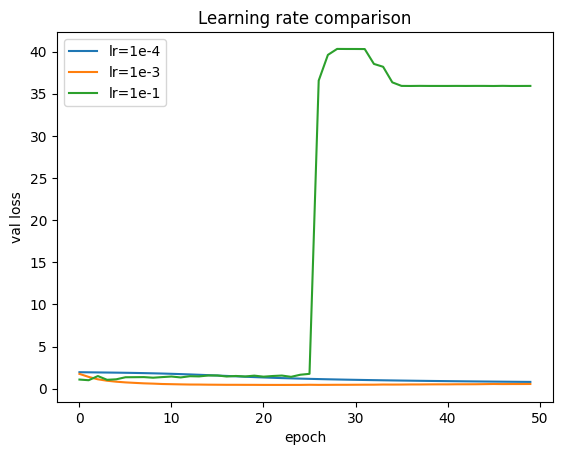

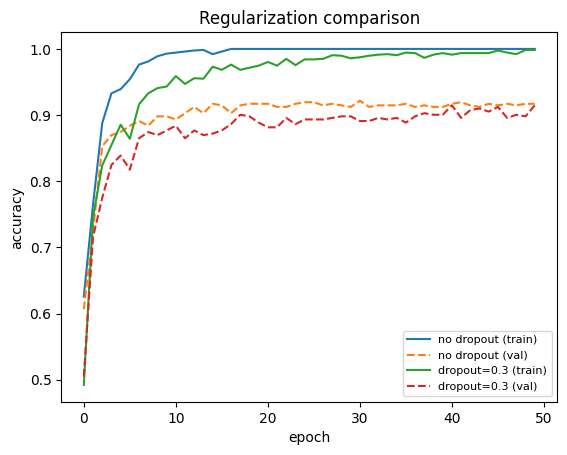

In [35]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

# Wrap Part 2.3's loop into a function
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    loader_train = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    loader_val   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

    m = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=lr)

    tr_losses, va_losses, tr_accs, va_accs = [], [], [], []

    for epoch in range(epochs):
        m.train()
        for xb, yb in loader_train:
            opt.zero_grad()
            logits = m(xb.to(DEVICE))
            loss = crit(logits, yb.to(DEVICE))
            loss.backward()
            opt.step()

        m.eval()
        with torch.no_grad():
            tr_correct, tr_total, tr_loss_sum = 0, 0, 0.0
            for xb, yb in loader_train:
                logits = m(xb.to(DEVICE))
                yb = yb.to(DEVICE)
                loss = crit(logits, yb)
                tr_loss_sum += loss.item() * xb.size(0)
                tr_correct += (logits.argmax(dim=1) == yb).sum().item()
                tr_total += xb.size(0)
            tr_loss = tr_loss_sum / tr_total
            tr_acc = tr_correct / tr_total

            va_correct, va_total, va_loss_sum = 0, 0, 0.0
            for xb, yb in loader_val:
                logits = m(xb.to(DEVICE))
                yb = yb.to(DEVICE)
                loss = crit(logits, yb)
                va_loss_sum += loss.item() * xb.size(0)
                va_correct += (logits.argmax(dim=1) == yb).sum().item()
                va_total += xb.size(0)
            va_loss = va_loss_sum / va_total
            va_acc = va_correct / va_total

        tr_losses.append(tr_loss); va_losses.append(va_loss)
        tr_accs.append(tr_acc); va_accs.append(va_acc)

    return {"train_losses": tr_losses, "val_losses": va_losses, "train_accs": tr_accs, "val_accs": va_accs}



result_tiny    = run_experiment(hidden_sizes=(8,))
result_default = run_experiment(hidden_sizes=(64, 32))
result_large   = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure()
plt.plot(result_tiny["val_accs"], label="tiny (8,)")
plt.plot(result_default["val_accs"], label="default (64,32)")
plt.plot(result_large["val_accs"], label="large (256,128,64)")
plt.xlabel("epoch"); plt.ylabel("val accuracy"); plt.title("Capacity comparison")
plt.legend()
plt.show()



result_lr_small = run_experiment(lr=1e-4)
result_lr_mid   = run_experiment(lr=1e-3)
result_lr_large = run_experiment(lr=1e-1)

plt.figure()
plt.plot(result_lr_small["val_losses"], label="lr=1e-4")
plt.plot(result_lr_mid["val_losses"], label="lr=1e-3")
plt.plot(result_lr_large["val_losses"], label="lr=1e-1")
plt.xlabel("epoch"); plt.ylabel("val loss"); plt.title("Learning rate comparison")
plt.legend()
plt.show()



result_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
result_dropout    = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

plt.figure()
plt.plot(result_no_dropout["train_accs"], label="no dropout (train)")
plt.plot(result_no_dropout["val_accs"], linestyle="--", label="no dropout (val)")
plt.plot(result_dropout["train_accs"], label="dropout=0.3 (train)")
plt.plot(result_dropout["val_accs"], linestyle="--", label="dropout=0.3 (val)")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Regularization comparison")
plt.legend(fontsize=8)
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.